# 01 — Baseline VLM (MedGemma sur RSNA)

> **Prototype pédagogique. Non destiné au diagnostic.** Toute sortie doit être vérifiée par un professionnel qualifié.

**Objectif (niveau Must).** Charger une radiographie, appeler le moteur avec le prompt *baseline*, appliquer les garde-fous (`src/guardrails.py`) et obtenir une sortie JSON structurée. C'est la brique « une image entre → une analyse tracée sort ».

**Où lancer ?** Depuis n'importe quel dossier : le notebook retrouve la racine du dépôt tout seul.

**Temps de calcul — dépend du matériel :**
- GPU NVIDIA 6 Go : ~15 s de chargement, puis ~20 s/image.
- **Sans GPU NVIDIA (CPU) : plusieurs minutes par image.**

👉 Pour une **démo instantanée** sans GPU ni téléchargement, mettez `ENGINE = 'toy'` dans la cellule de configuration ci-dessous (moteur à règles). Mettez `ENGINE = 'medgemma'` pour le vrai modèle vision-langage.

In [1]:
import sys, json, time
from pathlib import Path

# Retrouver la racine du dépôt, quel que soit le dossier de lancement du kernel.
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src').is_dir() and (candidate / 'prompts').is_dir():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT))

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from src.pipeline import predict
print('repo root:', ROOT)

repo root: C:\I1\S2\MasterCamp\Projet-ARVI-main


In [2]:
# --- Configuration ---
# 'medgemma' : vrai modèle vision-langage (précis, mais LENT sur CPU : plusieurs min/image).
# 'toy'      : moteur à règles instantané, sans GPU ni téléchargement (démo rapide).
ENGINE = 'medgemma'

# Diagnostic matériel : y a-t-il un GPU CUDA utilisable ?
try:
    import torch
    _gpu = torch.cuda.is_available()
    print('GPU CUDA disponible :', _gpu)
    if not _gpu and ENGINE == 'medgemma':
        print("ATTENTION : pas de GPU NVIDIA, MedGemma tournera sur CPU (plusieurs minutes/image).")
        print("Pour une demo instantanee, mettez ENGINE = 'toy' ci-dessus et re-executez.")
except ImportError:
    print("torch non installe : seule la config ENGINE = 'toy' fonctionnera.")

GPU CUDA disponible : False
ATTENTION : pas de GPU NVIDIA, MedGemma tournera sur CPU (plusieurs minutes/image).
Pour une demo instantanee, mettez ENGINE = 'toy' ci-dessus et re-executez.


## Choisir un cas RSNA

Le jeu de cas est décrit dans `data/rsna_cases.csv` (généré par `data/prepare_rsna.py`).

In [3]:
# Jeu de cas RSNA (généré par data/prepare_rsna.py).
# Repli automatique sur une image synthétique si le jeu RSNA n'est pas préparé.
cases_csv = ROOT / 'data' / 'rsna_cases.csv'
if cases_csv.exists():
    cases = pd.read_csv(cases_csv)
    print('Jeu RSNA -', dict(cases['label'].value_counts()))
    case = cases[cases['label'] == 'suspected_opacity'].iloc[0]
    image_path = ROOT / case['image_path']
    true_label = case['label']
else:
    print("data/rsna_cases.csv absent -> repli sur une image synthetique (data/sample_images).")
    print("Pour les vraies radios RSNA : python data/prepare_rsna.py --per-class 15")
    image_path = ROOT / 'data' / 'sample_images' / 'CXR_SYN_002_suspected_opacity.png'
    true_label = 'suspected_opacity'

assert image_path.exists(), f"Image introuvable : {image_path}"
print('image selectionnee :', image_path.relative_to(ROOT), '| verite terrain :', true_label)

Jeu RSNA - {'suspected_opacity': np.int64(15), 'normal': np.int64(15)}
image selectionnee : data\rsna_images\RSNA_001_suspected_opacity.png | verite terrain : suspected_opacity


In [4]:
# Inférence, prompt baseline. Le moteur (medgemma/toy) vient de la cellule de configuration.
# Sur CPU avec ENGINE='medgemma', cette cellule peut prendre plusieurs minutes.
t0 = time.time()
pred = predict(image_path, mode='baseline', engine=ENGINE)
print(f"Inférence '{ENGINE}' en {time.time() - t0:.1f} s (device: {pred.get('device', 'toy')})")
print(json.dumps(pred, indent=2, ensure_ascii=False))

C:\I1\S2\MasterCamp\Projet-ARVI-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/883 [00:06<1:37:23,  6.62s/it]

Loading weights:  14%|█▎        | 120/883 [00:07<00:32, 23.57it/s]

...

Loading weights:  97%|█████████▋| 855/883 [00:25<00:00, 81.31it/s]

Loading weights:  99%|█████████▊| 871/883 [00:25<00:00, 91.63it/s]

Loading weights: 100%|██████████| 883/883 [00:25<00:00, 34.37it/s]

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


Inférence 'medgemma' en 152.9 s (device: cpu)
{
  "image_quality": "good",
  "predicted_class": "suspected_opacity",
  "confidence": 0.6,
  "visual_evidence": [
    "Right lung appears hazy and dense.",
    "There is a possible opacity in the right lower lung field."
  ],
  "justification": "The right lung appears more opaque than the left lung, which could indicate consolidation or fluid accumulation. The right lower lung field shows a possible opacity, which could be due to pneumonia or other lung pathology. The image quality is good, allowing for visualization of the lung parenchyma.",
  "limitations": [
    "The image is a single frontal view, which limits the assessment of the lung fields.",
    "The patient has medical devices in place, which could obscure the lung fields.",
    "not a validated medical model",
    "no clinical context"
  ],
  "warning": "Prototype pédagogique. Non destiné au diagnostic. Validation par un professionnel qualifié requise.",
  "model_name": "google/

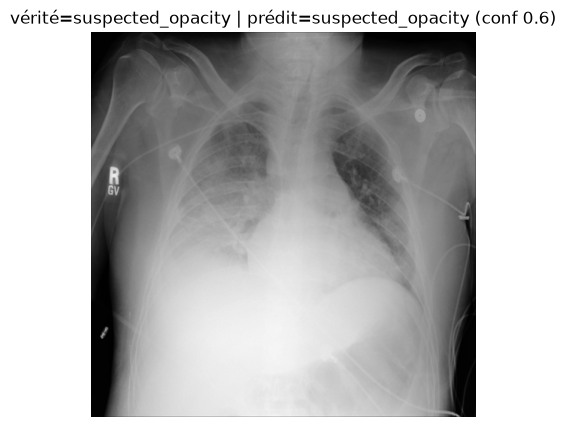

Justification : The right lung appears more opaque than the left lung, which could indicate consolidation or fluid accumulation. The right lower lung field shows a possible opacity, which could be due to pneumonia or other lung pathology. The image quality is good, allowing for visualization of the lung parenchyma.


In [5]:
# Visualiser l'image et la prédiction côte à côte
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(Image.open(image_path), cmap='gray')
ax.axis('off')
ax.set_title(f"vérité={true_label} | prédit={pred['predicted_class']} (conf {pred['confidence']})")
plt.show()
print('Justification :', pred['justification'])
print('Warning        :', pred['warning'])

## À retenir

- La sortie respecte le schéma (`predicted_class`, `confidence`, `visual_evidence`, `justification`, `limitations`, `warning`).
- Les garde-fous (`src/guardrails.py`) forcent `uncertain` si le JSON est invalide ou la qualité image faible.
- Pour évaluer tout le jeu : voir le notebook **02** et `eval/run_evaluation.py`.